In [13]:
import numpy as np
from data import *
import matplotlib.pyplot as plt

In [14]:
def visualize_data(X,y):
    fig ,ax = plt.subplots(figsize=(6,6))
    ax.scatter(X[y == 0, 0], X[y == 0, 1],c="red", label="Class 0")
    ax.scatter(X[y == 1, 0], X[y == 1, 1],c="blue", label="Class 1")
    plt.legend()
    plt.show()

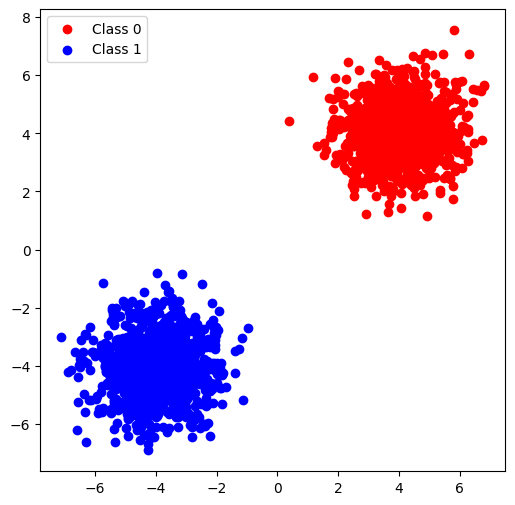

In [15]:

X,y,_ = load_bubbles()
visualize_data(X,y)

In [16]:
from epiuc.uncertainty.classification import MLP_Classifier
from epiuc.uncertainty.wrapper import Ensemble_Classifier
ENSEMBLE_MEMBER_COUNT = 20
base_ensemble = [MLP_Classifier(input_shape=2,n_classes=2,n_layers=2,num_neurons=64,dropout_prob=0,batch_norm=False,) for  _ in range(ENSEMBLE_MEMBER_COUNT)]
ensemble_model = Ensemble_Classifier(base_ensemble,n_models=ENSEMBLE_MEMBER_COUNT)
ensemble_model.load("../models/Ensemble_Bubbles_50/")

In [17]:
X_label1 = X[y == 1]
X_label0 = X[y == 0]

point_of_interest = np.array([[3,3]])

In [18]:
def get_costs(X, point_of_interest, desired_class=1):
    """
    Calculate the costs for each point in X with respect to the point of interest.
    :param X: The data points
    :param point_of_interest: The point of interest
    :return: An array of costs
    """
    probabilities,_ = ensemble_model.predict(X)
    probabilities = probabilities.detach().log2().mul(-1).numpy()[:,desired_class]  # Convert to log2 probabilities
    distances = np.linalg.norm(X - point_of_interest, axis=1)
    return np.vstack([distances, probabilities]).T



In [19]:
combined_costs = get_costs(X_label1, point_of_interest)

In [20]:
def is_pareto_efficient(costs, return_mask = True):
    """
    Find the pareto-efficient points
    :param costs: An (n_points, n_costs) array
    :param return_mask: True to return a mask
    :return: An array of indices of pareto-efficient points.
        If return_mask is True, this will be an (n_points, ) boolean array
        Otherwise it will be a (n_efficient_points, ) integer array of indices.
    """
    is_efficient = np.arange(costs.shape[0])
    n_points = costs.shape[0]
    next_point_index = 0  # Next index in the is_efficient array to search for
    while next_point_index<len(costs):
        nondominated_point_mask = np.any(costs<costs[next_point_index], axis=1)
        nondominated_point_mask[next_point_index] = True
        is_efficient = is_efficient[nondominated_point_mask]  # Remove dominated points
        costs = costs[nondominated_point_mask]
        next_point_index = np.sum(nondominated_point_mask[:next_point_index])+1
    if return_mask:
        is_efficient_mask = np.zeros(n_points, dtype = bool)
        is_efficient_mask[is_efficient] = True
        return is_efficient_mask
    else:
        return is_efficient

In [21]:
pareto_front = X_label1[is_pareto_efficient(combined_costs)]

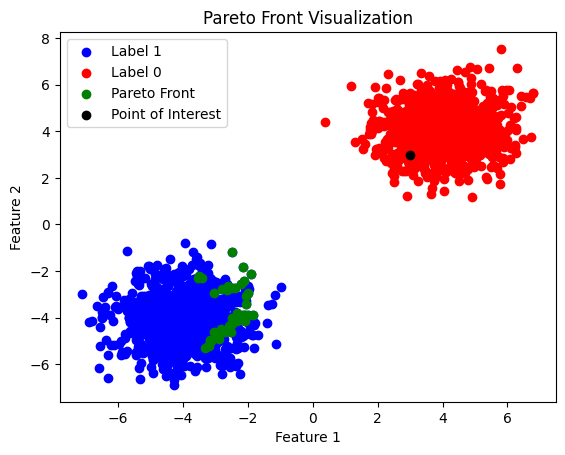

In [22]:
plt.scatter(X_label1[:,0], X_label1[:,1], c="blue", label="Label 1")
plt.scatter(X_label0[:,0], X_label0[:,1], c="red", label="Label 0")
plt.scatter(pareto_front[:,0], pareto_front[:,1], c="green", label="Pareto Front")
plt.scatter(point_of_interest[0,0], point_of_interest[0,1], c="black", label="Point of Interest")
plt.legend()
plt.title("Pareto Front Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

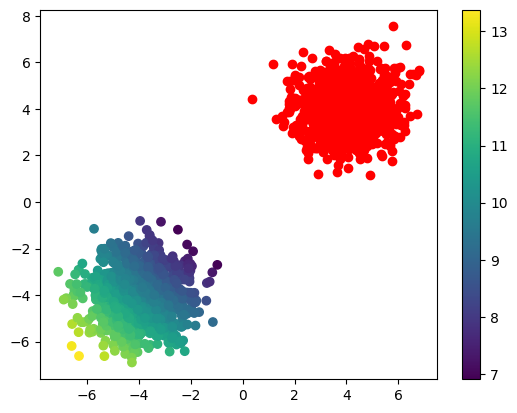

In [23]:
plot = plt.scatter(X_label1[:,0], X_label1[:,1], c=combined_costs[:,0], label="Label 1")
plt.scatter(X_label0[:,0], X_label0[:,1], c="red", label="Label 0")
plt.colorbar(plot)
plt.show()

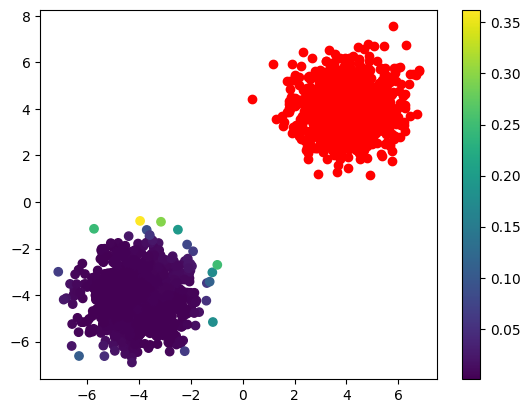

In [24]:
plot = plt.scatter(X_label1[:,0], X_label1[:,1], c=combined_costs[:,1], label="Label 1")
plt.scatter(X_label0[:,0], X_label0[:,1], c="red", label="Label 0")
plt.colorbar(plot)
plt.show()